# Ride Demand Forecasting Data Prep Engine

**Practical Exam | Set C — Data Preprocessing and Feature Engineering**

Objective: build a complete data preprocessing & feature engineering pipeline
that prepares real-world ride-hailing trip data (CSV, JSON, SQL) for
downstream analytics and predictive modeling (ride demand forecasting,
surge pricing prediction).


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, OrdinalEncoder,
    StandardScaler, MinMaxScaler
)
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

DATA_DIR = "../data"


## 1. Data Understanding & Loading

In [2]:
# Load CSV
riders = pd.read_csv(f"{DATA_DIR}/riders.csv")

# Load JSON
with open(f"{DATA_DIR}/trips.json", "r") as f:
    trips_raw = json.load(f)
trips = pd.DataFrame(trips_raw)

# Load SQL (script contains CREATE TABLE + INSERT statements -> load into sqlite, then read back)
conn = sqlite3.connect(":memory:")
with open(f"{DATA_DIR}/city_zones.sql", "r") as f:
    sql_script = f.read()
conn.executescript(sql_script)
city_zones = pd.read_sql("SELECT * FROM city_zones;", conn)

print("riders:", riders.shape)
print("trips:", trips.shape)
print("city_zones:", city_zones.shape)


riders: (515, 8)
trips: (3060, 9)
city_zones: (16, 5)


In [3]:
print("=== riders.csv — first 5 rows ===")
riders.head()

=== riders.csv — first 5 rows ===


,rider_id,name,age,gender,signup_date,ride_payment_mode,rider_rating,home_zone_id
0,1,John Iyer,25.0,Male,01-30-2024,Cash,4.15,8
1,2,Aryan Iyer,25.0,Other,2024-01-29,UPI,5.00,2
2,3,Aarav Gupta,31.0,Male,2022-08-27,Cash,3.77,14
3,4,Sai Miller,40.0,Other,2022-10-12,Cash,3.69,14
4,5,Ananya Singh,34.0,Male,08-09-2022,Card,3.32,3


In [4]:
print("=== trips.json — first 5 rows ===")
trips.head()

=== trips.json — first 5 rows ===


,trip_id,rider_id,zone_id,trip_datetime,distance_km,trip_duration_min,fare_amount,cancelled,payment_mode
0,1,499,3,2024-07-30T10:51:00,3.61,9.3,58.65,0,Card
1,2,304,2,2024-06-07T08:56:00,3.27,13.9,44.99,0,Wallet
2,3,475,13,2024-04-28T18:49:00,2.82,8.6,NaN,0,Cash
3,4,70,4,2024-02-26T13:59:00,6.96,18.9,NaN,0,Card
4,5,275,12,2024-03-16T14:21:00,10.83,33.4,148.82,0,Card


In [5]:
print("=== city_zones.sql — first 5 rows ===")
city_zones.head()

=== city_zones.sql — first 5 rows ===


,zone_id,zone_name,avg_traffic_index,population_density,traffic_level
0,1,Downtown Core,4.37,23841,Medium
1,2,Riverside,7.59,15568,High
2,3,Tech Park,2.40,5165,Low
3,4,Old Town,1.52,21855,Low
4,5,Airport District,6.41,18139,Medium


In [6]:
print("=== riders.info() ===")
riders.info()

=== riders.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rider_id           515 non-null    int64  
 1   name               515 non-null    str    
 2   age                484 non-null    float64
 3   gender             490 non-null    str    
 4   signup_date        515 non-null    str    
 5   ride_payment_mode  500 non-null    str    
 6   rider_rating       495 non-null    float64
 7   home_zone_id       515 non-null    int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 32.3 KB


In [7]:
print("=== trips.info() ===")
trips.info()

=== trips.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   trip_id            3060 non-null   int64  
 1   rider_id           3060 non-null   int64  
 2   zone_id            3060 non-null   int64  
 3   trip_datetime      3060 non-null   str    
 4   distance_km        2938 non-null   float64
 5   trip_duration_min  2907 non-null   float64
 6   fare_amount        2909 non-null   float64
 7   cancelled          3060 non-null   int64  
 8   payment_mode       3060 non-null   str    
dtypes: float64(3), int64(4), str(2)
memory usage: 215.3 KB


In [8]:
print("=== city_zones.info() ===")
city_zones.info()

=== city_zones.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   zone_id             16 non-null     int64  
 1   zone_name           16 non-null     str    
 2   avg_traffic_index   16 non-null     float64
 3   population_density  16 non-null     int64  
 4   traffic_level       16 non-null     str    
dtypes: float64(1), int64(2), str(2)
memory usage: 772.0 bytes


In [9]:
print("Missing values — riders:")
print(riders.isna().sum())
print("\nMissing values — trips:")
print(trips.isna().sum())
print("\nMissing values — city_zones:")
print(city_zones.isna().sum())


Missing values — riders:
rider_id              0
name                  0
age                  31
gender               25
signup_date           0
ride_payment_mode    15
rider_rating         20
home_zone_id          0
dtype: int64

Missing values — trips:
trip_id                0
rider_id               0
zone_id                0
trip_datetime          0
distance_km          122
trip_duration_min    153
fare_amount          151
cancelled              0
payment_mode           0
dtype: int64

Missing values — city_zones:
zone_id               0
zone_name             0
avg_traffic_index     0
population_density    0
traffic_level         0
dtype: int64


In [10]:
# Duplicate check
print("Duplicate rows in riders:", riders.duplicated().sum())
print("Duplicate rows in trips:", trips.duplicated(subset=[c for c in trips.columns if c != 'trip_id']).sum())
print("Duplicate rows in city_zones:", city_zones.duplicated().sum())


Duplicate rows in riders: 15
Duplicate rows in trips: 60
Duplicate rows in city_zones: 0


In [11]:
# Invalid entries check
print("Riders with age < 10:", (riders['age'] < 10).sum())
print("Trips with negative distance:", (trips['distance_km'] < 0).sum())
print("Trips with negative fare:", (trips['fare_amount'] < 0).sum())
print("Zero-distance but billed rides:", ((trips['distance_km'] == 0) & (trips['fare_amount'] > 0)).sum())


Riders with age < 10: 16
Trips with negative distance: 0
Trips with negative fare: 29
Zero-distance but billed rides: 31


## 2. Data Cleaning

- Numeric missing values → `SimpleImputer(strategy='mean')`
- Categorical missing values → `SimpleImputer(strategy='most_frequent')`
- Multivariate numeric columns (trip duration, distance, fare) → `KNNImputer`
- Convert inconsistent date formats
- Remove unrealistic entries (negative fare, zero-distance billed rides, age < 10)
- Drop duplicates


In [12]:
# --- riders: drop exact duplicates ---
before = len(riders)
riders = riders.drop_duplicates().reset_index(drop=True)
print(f"riders: dropped {before - len(riders)} duplicate rows")

# --- riders: categorical missing values -> most frequent ---
cat_cols_riders = ["gender", "ride_payment_mode"]
cat_imputer = SimpleImputer(strategy="most_frequent")
riders[cat_cols_riders] = cat_imputer.fit_transform(riders[cat_cols_riders])

# --- riders: numeric missing values -> mean ---
num_cols_riders = ["rider_rating"]
num_imputer = SimpleImputer(strategy="mean")
riders[num_cols_riders] = num_imputer.fit_transform(riders[num_cols_riders])

# age has missing values AND invalid low values -> handle together below
riders["age"] = pd.to_numeric(riders["age"], errors="coerce")


riders: dropped 15 duplicate rows


In [13]:
# --- riders: convert inconsistent signup_date formats to a single standard (datetime) ---
def parse_mixed_date(value):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%m-%d-%Y", "%d-%b-%Y"):
        try:
            return pd.to_datetime(value, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.to_datetime(value, errors="coerce")  # fallback

riders["signup_date"] = riders["signup_date"].apply(parse_mixed_date)
print(riders["signup_date"].head())
print("Unparsed signup dates:", riders["signup_date"].isna().sum())


0   2024-01-30
1   2024-01-29
2   2022-08-27
3   2022-10-12
4   2022-08-09
Name: signup_date, dtype: datetime64[us]
Unparsed signup dates: 0


In [14]:
# --- riders: remove unrealistic entries (age < 10), then impute remaining age NaNs with mean ---
invalid_age_mask = riders["age"] < 10
print("Unrealistic ages (<10) flagged for removal:", invalid_age_mask.sum())
riders = riders[~invalid_age_mask].reset_index(drop=True)

riders["age"] = SimpleImputer(strategy="mean").fit_transform(riders[["age"]])
print(riders["age"].describe())


Unrealistic ages (<10) flagged for removal: 15


count    485.000000
mean      32.070330
std        9.136222
min       10.000000
25%       26.000000
50%       32.000000
75%       37.000000
max       62.000000
Name: age, dtype: float64


In [15]:
# --- trips: drop duplicates (keep first occurrence, ignore trip_id) ---
before = len(trips)
trips = trips.drop_duplicates(subset=[c for c in trips.columns if c != "trip_id"]).reset_index(drop=True)
print(f"trips: dropped {before - len(trips)} duplicate rows")

# --- trips: convert trip_datetime to datetime dtype ---
trips["trip_datetime"] = pd.to_datetime(trips["trip_datetime"], errors="coerce")


trips: dropped 60 duplicate rows


In [16]:
# --- trips: remove unrealistic entries ---
before = len(trips)

# Negative fare -> unrealistic, remove
neg_fare_mask = trips["fare_amount"] < 0
# Zero-distance ride but billed -> unrealistic, remove
zero_dist_billed_mask = (trips["distance_km"] == 0) & (trips["fare_amount"] > 0)

remove_mask = neg_fare_mask.fillna(False) | zero_dist_billed_mask.fillna(False)
print("Negative fare rows:", neg_fare_mask.sum())
print("Zero-distance-but-billed rows:", zero_dist_billed_mask.sum())

trips = trips[~remove_mask].reset_index(drop=True)
print(f"trips: removed {before - len(trips)} unrealistic rows -> new shape {trips.shape}")


Negative fare rows: 29
Zero-distance-but-billed rows: 29
trips: removed 58 unrealistic rows -> new shape (2942, 9)


In [17]:
# --- trips: multivariate missing-value imputation with KNNImputer ---
# Columns: trip_duration_min, distance_km, fare_amount
knn_cols = ["trip_duration_min", "distance_km", "fare_amount"]
print("Missing before KNN imputation:")
print(trips[knn_cols].isna().sum())

knn_imputer = KNNImputer(n_neighbors=5)
trips[knn_cols] = knn_imputer.fit_transform(trips[knn_cols])

print("\nMissing after KNN imputation:")
print(trips[knn_cols].isna().sum())


Missing before KNN imputation:
trip_duration_min    145
distance_km          117
fare_amount          150
dtype: int64



Missing after KNN imputation:
trip_duration_min    0
distance_km          0
fare_amount          0
dtype: int64


## 3. Outlier Handling

- **Z-score method** for fare & distance anomalies
- **IQR method** for ride duration anomalies
- **Winsorization** for extreme surge fares
- Before vs after comparison


In [18]:
outlier_before_stats = trips[["fare_amount", "distance_km", "trip_duration_min"]].describe().T
outlier_before_stats


,count,mean,std,min,25%,50%,75%,max
fare_amount,2942.0,90.692991,116.679402,16.05,42.1275,64.27,105.31,3332.520842
distance_km,2942.0,5.787508,7.224876,0.00,1.9500,3.88,7.40,161.444709
trip_duration_min,2942.0,19.625595,34.775211,1.00,6.4000,12.47,23.70,1082.598717


In [19]:
# --- Z-score method: fare & distance anomalies ---
z_fare = np.abs(stats.zscore(trips["fare_amount"]))
z_distance = np.abs(stats.zscore(trips["distance_km"]))

Z_THRESH = 3
fare_outliers_z = (z_fare > Z_THRESH).sum()
distance_outliers_z = (z_distance > Z_THRESH).sum()
print(f"Fare anomalies (|z| > {Z_THRESH}): {fare_outliers_z}")
print(f"Distance anomalies (|z| > {Z_THRESH}): {distance_outliers_z}")

z_outlier_mask = (z_fare > Z_THRESH) | (z_distance > Z_THRESH)


Fare anomalies (|z| > 3): 32
Distance anomalies (|z| > 3): 40


In [20]:
# --- IQR method: ride duration anomalies ---
Q1 = trips["trip_duration_min"].quantile(0.25)
Q3 = trips["trip_duration_min"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

duration_outlier_mask = (trips["trip_duration_min"] < lower_bound) | (trips["trip_duration_min"] > upper_bound)
print(f"Duration anomalies (IQR method): {duration_outlier_mask.sum()}")
print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}] minutes")


Duration anomalies (IQR method): 180


IQR bounds: [-19.55, 49.65] minutes


In [21]:
# --- Winsorization: cap extreme surge fares at the 1st / 99th percentile ---
lower_p, upper_p = trips["fare_amount"].quantile([0.01, 0.99])
trips["fare_amount"] = trips["fare_amount"].clip(lower=lower_p, upper=upper_p)

# Cap distance using the same z-score-informed bounds (winsorize at 1st/99th pct too)
lower_pd, upper_pd = trips["distance_km"].quantile([0.01, 0.99])
trips["distance_km"] = trips["distance_km"].clip(lower=lower_pd, upper=upper_pd)

# Cap duration using IQR bounds
trips["trip_duration_min"] = trips["trip_duration_min"].clip(lower=max(lower_bound, 0), upper=upper_bound)

print("Winsorization applied to fare_amount, distance_km, trip_duration_min")


Winsorization applied to fare_amount, distance_km, trip_duration_min


In [22]:
outlier_after_stats = trips[["fare_amount", "distance_km", "trip_duration_min"]].describe().T

comparison = pd.concat(
    [outlier_before_stats[["mean", "std", "min", "max"]].add_prefix("before_"),
     outlier_after_stats[["mean", "std", "min", "max"]].add_prefix("after_")],
    axis=1
)
comparison


,before_mean,before_std,before_min,before_max,after_mean,after_std,after_min,after_max
fare_amount,90.692991,116.679402,16.05,3332.520842,86.502203,71.320598,20.0479,469.601944
distance_km,5.787508,7.224876,0.00,161.444709,5.597039,5.366989,0.5500,30.662248
trip_duration_min,19.625595,34.775211,1.00,1082.598717,16.832715,13.829095,1.0000,49.650000


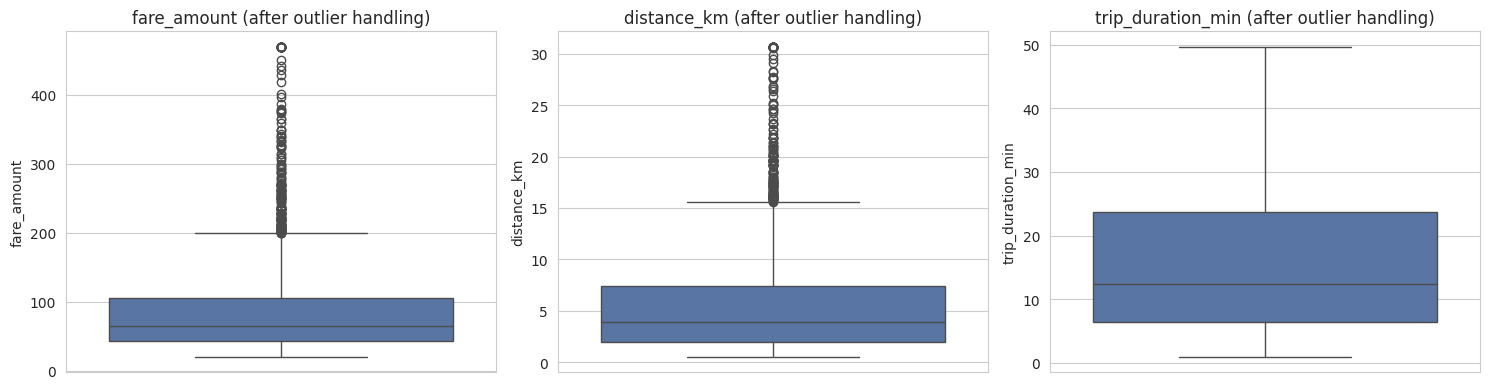

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["fare_amount", "distance_km", "trip_duration_min"]):
    sns.boxplot(y=trips[col], ax=ax, color="#4C72B0")
    ax.set_title(f"{col} (after outlier handling)")
plt.tight_layout()
plt.savefig("../output/outlier_handling_boxplots.png", dpi=120)
plt.show()


## 4. Data Transformation

- Extract `hour`, `day_of_week`, `month` from datetime
- Encode categorical columns (Label / One-Hot / Ordinal)
- Binning of customer ride frequency
- Log / square-root transforms on skewed numeric columns


In [24]:
# --- datetime -> hour, day_of_week, month ---
trips["hour"] = trips["trip_datetime"].dt.hour
trips["day_of_week"] = trips["trip_datetime"].dt.day_name()
trips["month"] = trips["trip_datetime"].dt.month

trips[["trip_datetime", "hour", "day_of_week", "month"]].head()


,trip_datetime,hour,day_of_week,month
0,2024-07-30 10:51:00,10,Tuesday,7
1,2024-06-07 08:56:00,8,Friday,6
2,2024-04-28 18:49:00,18,Sunday,4
3,2024-02-26 13:59:00,13,Monday,2
4,2024-03-16 14:21:00,14,Saturday,3


In [25]:
# --- Merge zone attributes onto trips (needed for traffic_level ordinal encoding) ---
trips = trips.merge(city_zones, on="zone_id", how="left", suffixes=("", "_zone"))
trips.rename(columns={"zone_name": "zone_name"}, inplace=True)
trips.head()


,trip_id,rider_id,zone_id,trip_datetime,distance_km,trip_duration_min,fare_amount,cancelled,payment_mode,hour,day_of_week,month,zone_name,avg_traffic_index,population_density,traffic_level
0,1,499,3,2024-07-30 10:51:00,3.61,9.3,58.650,0,Card,10,Tuesday,7,Tech Park,2.40,5165,Low
1,2,304,2,2024-06-07 08:56:00,3.27,13.9,44.990,0,Wallet,8,Friday,6,Riverside,7.59,15568,High
2,3,475,13,2024-04-28 18:49:00,2.82,8.6,53.830,0,Cash,18,Sunday,4,Central Market,5.10,19951,Medium
3,4,70,4,2024-02-26 13:59:00,6.96,18.9,109.022,0,Card,13,Monday,2,Old Town,1.52,21855,Low
4,5,275,12,2024-03-16 14:21:00,10.83,33.4,148.820,0,Card,14,Saturday,3,Lakeview,3.63,10109,Low


In [26]:
# --- Encode categorical columns ---

# Label Encode: gender (on riders table)
le_gender = LabelEncoder()
riders["gender_encoded"] = le_gender.fit_transform(riders["gender"])
print("Gender classes:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

# One-Hot Encode: ride_payment_mode (riders), zone_name (trips)
riders = pd.get_dummies(riders, columns=["ride_payment_mode"], prefix="pay")
trips = pd.get_dummies(trips, columns=["zone_name"], prefix="zone")

# Ordinal Encode: traffic_level (Low < Medium < High)
traffic_order = [["Low", "Medium", "High"]]
ord_encoder = OrdinalEncoder(categories=traffic_order)
trips["traffic_level_encoded"] = ord_encoder.fit_transform(trips[["traffic_level"]])

trips[["traffic_level", "traffic_level_encoded"]].drop_duplicates().sort_values("traffic_level_encoded")


Gender classes: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}


,traffic_level,traffic_level_encoded
0,Low,0.0
2,Medium,1.0
1,High,2.0


In [27]:
# --- Binning: customer ride frequency (Low/Med/High) ---
ride_counts = trips.groupby("rider_id")["trip_id"].count().rename("ride_count")
riders = riders.merge(ride_counts, left_on="rider_id", right_index=True, how="left")
riders["ride_count"] = riders["ride_count"].fillna(0)

riders["ride_frequency_bin"] = pd.qcut(
    riders["ride_count"].rank(method="first"),
    q=3,
    labels=["Low", "Medium", "High"]
)
riders[["rider_id", "ride_count", "ride_frequency_bin"]].head()


,rider_id,ride_count,ride_frequency_bin
0,1,4.0,Low
1,2,11.0,High
2,3,8.0,High
3,4,6.0,Medium
4,5,5.0,Low


In [28]:
# --- Transform skewed numeric columns ---
print("Skewness before transform:")
print("fare_amount:", trips["fare_amount"].skew().round(3))
print("distance_km:", trips["distance_km"].skew().round(3))
print("trip_duration_min:", trips["trip_duration_min"].skew().round(3))

# Log transform on fare and distance (log1p handles zero-safe)
trips["fare_amount_log"] = np.log1p(trips["fare_amount"])
trips["distance_km_log"] = np.log1p(trips["distance_km"])

# Square-root transform on duration
trips["trip_duration_min_sqrt"] = np.sqrt(trips["trip_duration_min"])

print("\nSkewness after transform:")
print("fare_amount_log:", trips["fare_amount_log"].skew().round(3))
print("distance_km_log:", trips["distance_km_log"].skew().round(3))
print("trip_duration_min_sqrt:", trips["trip_duration_min_sqrt"].skew().round(3))


Skewness before transform:
fare_amount: 2.714
distance_km: 2.128
trip_duration_min: 1.049

Skewness after transform:
fare_amount_log: 0.506
distance_km_log: 0.327
trip_duration_min_sqrt: 0.356


## 5. Feature Scaling

- `StandardScaler` and `MinMaxScaler` on numeric features
- Before vs after stats (mean / std / min / max)


In [29]:
scale_cols = ["fare_amount", "distance_km", "trip_duration_min"]

before_scale_stats = trips[scale_cols].agg(["mean", "std", "min", "max"]).T

standard_scaler = StandardScaler()
trips[[c + "_standard" for c in scale_cols]] = standard_scaler.fit_transform(trips[scale_cols])

minmax_scaler = MinMaxScaler()
trips[[c + "_minmax" for c in scale_cols]] = minmax_scaler.fit_transform(trips[scale_cols])

after_standard_stats = trips[[c + "_standard" for c in scale_cols]].agg(["mean", "std", "min", "max"]).T
after_minmax_stats = trips[[c + "_minmax" for c in scale_cols]].agg(["mean", "std", "min", "max"]).T

print("=== Before scaling ===")
display(before_scale_stats)
print("=== After StandardScaler ===")
display(after_standard_stats)
print("=== After MinMaxScaler ===")
display(after_minmax_stats)


=== Before scaling ===


,mean,std,min,max
fare_amount,86.502203,71.320598,20.0479,469.601944
distance_km,5.597039,5.366989,0.5500,30.662248
trip_duration_min,16.832715,13.829095,1.0000,49.650000


=== After StandardScaler ===


,mean,std,min,max
fare_amount_standard,-3.381237e-17,1.00017,-0.931927,5.372429
distance_km_standard,4.468063e-17,1.00017,-0.940545,4.671049
trip_duration_min_standard,9.358780e-17,1.00017,-1.145079,2.373464


=== After MinMaxScaler ===


,mean,std,min,max
fare_amount_minmax,0.147823,0.158647,0.0,1.0
distance_km_minmax,0.167608,0.178233,0.0,1.0
trip_duration_min_minmax,0.325441,0.284257,0.0,1.0


## 6. Feature Construction

Engineer ML-ready features:

| Feature | Logic |
|---|---|
| `avg_ride_distance` | total distance / total trips |
| `avg_ride_fare` | total fare / rides |
| `is_peak_hour` | 1 if hour in [7-9, 18-21] else 0 |
| `days_since_signup` | today − signup_date |
| `ride_cancellation_rate` | cancelled_rides / total_rides |
| `surge_flag` | 1 if fare/distance > threshold |


In [30]:
# --- Per-rider aggregate features ---
agg = trips.groupby("rider_id").agg(
    total_distance=("distance_km", "sum"),
    total_trips=("trip_id", "count"),
    total_fare=("fare_amount", "sum"),
    cancelled_rides=("cancelled", "sum")
).reset_index()

agg["avg_ride_distance"] = agg["total_distance"] / agg["total_trips"]
agg["avg_ride_fare"] = agg["total_fare"] / agg["total_trips"]
agg["ride_cancellation_rate"] = agg["cancelled_rides"] / agg["total_trips"]

riders = riders.merge(
    agg[["rider_id", "avg_ride_distance", "avg_ride_fare", "ride_cancellation_rate"]],
    on="rider_id", how="left"
)
riders[["avg_ride_distance", "avg_ride_fare", "ride_cancellation_rate"]] = \
    riders[["avg_ride_distance", "avg_ride_fare", "ride_cancellation_rate"]].fillna(0)

riders[["rider_id", "avg_ride_distance", "avg_ride_fare", "ride_cancellation_rate"]].head()


,rider_id,avg_ride_distance,avg_ride_fare,ride_cancellation_rate
0,1,5.532500,80.332500,0.000000
1,2,4.407273,70.310909,0.090909
2,3,5.989500,89.405000,0.000000
3,4,12.040375,166.593657,0.166667
4,5,1.420000,34.829580,0.200000


In [31]:
# --- is_peak_hour (trip-level) ---
trips["is_peak_hour"] = trips["hour"].apply(lambda h: 1 if (7 <= h <= 9) or (18 <= h <= 21) else 0)

# --- days_since_signup (rider-level) ---
TODAY = pd.Timestamp("2026-08-25")
riders["days_since_signup"] = (TODAY - riders["signup_date"]).dt.days

# --- surge_flag (trip-level): 1 if fare/distance ratio exceeds threshold ---
trips["fare_per_km"] = trips["fare_amount"] / trips["distance_km"].replace(0, np.nan)
surge_threshold = trips["fare_per_km"].quantile(0.90)
trips["surge_flag"] = (trips["fare_per_km"] > surge_threshold).astype(int)

print("Peak-hour trips:", trips["is_peak_hour"].sum(), "/", len(trips))
print("Surge threshold (fare per km):", round(surge_threshold, 2))
print("Surge-flagged trips:", trips["surge_flag"].sum(), "/", len(trips))
riders[["rider_id", "days_since_signup"]].head()


Peak-hour trips: 847 / 2942
Surge threshold (fare per km): 30.73
Surge-flagged trips: 295 / 2942


,rider_id,days_since_signup
0,1,938
1,2,939
2,3,1459
3,4,1413
4,5,1477


## 7. Final Dataset

- Merge cleaned & enriched datasets
- Produce a before-vs-after summary table
- Export `final_prepared_rides_dataset.csv`


In [32]:
# --- Merge cleaned & enriched datasets into one model-ready table ---
final_dataset = trips.merge(
    riders,
    on="rider_id",
    how="left",
    suffixes=("_trip", "_rider")
)

print("Final merged dataset shape:", final_dataset.shape)
final_dataset.head()


Final merged dataset shape: (2942, 61)


,trip_id,rider_id,zone_id,trip_datetime,distance_km,trip_duration_min,fare_amount,cancelled,payment_mode,hour,day_of_week,month,avg_traffic_index,population_density,traffic_level,zone_Airport District,zone_Central Market,zone_Downtown Core,zone_East End,zone_Greenwood Hills,zone_Harbor Bay,zone_Hillcrest,zone_Industrial Zone,zone_Lakeview,zone_North Ridge,...,distance_km_standard,trip_duration_min_standard,fare_amount_minmax,distance_km_minmax,trip_duration_min_minmax,is_peak_hour,fare_per_km,surge_flag,name,age,gender,signup_date,rider_rating,home_zone_id,gender_encoded,pay_Card,pay_Cash,pay_UPI,pay_Wallet,ride_count,ride_frequency_bin,avg_ride_distance,avg_ride_fare,ride_cancellation_rate,days_since_signup
0,1,499,3,2024-07-30 10:51:00,3.61,9.3,58.650,0,Card,10,Tuesday,7,2.40,5165,Low,False,False,False,False,False,False,False,False,False,False,...,-0.370296,-0.544793,0.085868,0.101620,0.170606,0,16.246537,0,Anika Reddy,49.0,Female,2023-05-19,4.520000,9.0,0.0,False,True,False,False,7.0,High,9.657464,157.318563,0.0,1194.0
1,2,304,2,2024-06-07 08:56:00,3.27,13.9,44.990,0,Wallet,8,Friday,6,7.59,15568,High,False,False,False,False,False,False,False,False,False,False,...,-0.433657,-0.212105,0.055482,0.090329,0.265159,1,13.758410,0,Diya Verma,21.0,Female,2022-02-22,3.470000,10.0,0.0,False,False,False,True,8.0,High,4.948750,75.668750,0.0,1645.0
2,3,475,13,2024-04-28 18:49:00,2.82,8.6,53.830,0,Cash,18,Sunday,4,5.10,19951,Medium,False,True,False,False,False,False,False,False,False,False,...,-0.517518,-0.595420,0.075146,0.075385,0.156218,1,19.088652,0,Kiara Walker,27.0,Male,2023-06-25,4.307042,11.0,1.0,False,False,False,True,9.0,High,3.710000,66.686889,0.0,1157.0
3,4,70,4,2024-02-26 13:59:00,6.96,18.9,109.022,0,Card,13,Monday,2,1.52,21855,Low,False,False,False,False,False,False,False,False,False,False,...,0.253996,0.149513,0.197916,0.212870,0.367934,0,15.664080,0,Myra Brown,40.0,Female,2024-02-06,5.000000,13.0,0.0,False,False,False,True,9.0,High,7.584444,100.938000,0.0,931.0
4,5,275,12,2024-03-16 14:21:00,10.83,33.4,148.820,0,Card,14,Saturday,3,3.63,10109,Low,False,False,False,False,False,False,False,False,True,False,...,0.975193,1.198206,0.286444,0.341389,0.665982,0,13.741459,0,John Singh,34.0,Male,2022-04-27,4.690000,16.0,1.0,False,True,False,False,5.0,Medium,5.520000,90.764000,0.0,1581.0


In [33]:
# --- Reload RAW versions (for the before/after summary only) ---
riders_raw = pd.read_csv(f"{DATA_DIR}/riders.csv")
with open(f"{DATA_DIR}/trips.json") as f:
    trips_raw_records = json.load(f)
trips_raw_df = pd.DataFrame(trips_raw_records)

rows_before = len(riders_raw) + len(trips_raw_df)
rows_after = len(riders) + len(trips)

missing_before = int(riders_raw.isna().sum().sum() + trips_raw_df.isna().sum().sum())
missing_after = int(riders.isna().sum().sum() + trips.isna().sum().sum())

outliers_before = int(fare_outliers_z + distance_outliers_z + duration_outlier_mask.sum())
outliers_after = int(
    (np.abs(stats.zscore(trips['fare_amount'])) > Z_THRESH).sum()
    + (np.abs(stats.zscore(trips['distance_km'])) > Z_THRESH).sum()
)

new_features = [
    "hour", "day_of_week", "month", "traffic_level_encoded",
    "fare_amount_log", "distance_km_log", "trip_duration_min_sqrt",
    "fare_amount_standard", "distance_km_standard", "trip_duration_min_standard",
    "fare_amount_minmax", "distance_km_minmax", "trip_duration_min_minmax",
    "avg_ride_distance", "avg_ride_fare", "ride_cancellation_rate",
    "is_peak_hour", "days_since_signup", "surge_flag", "ride_frequency_bin",
    "gender_encoded"
]

summary_table = pd.DataFrame({
    "Metric": [
        "Rows (riders + trips combined)",
        "Missing values (total)",
        "Outliers (fare/distance/duration flags)",
        "New engineered features"
    ],
    "Before": [rows_before, missing_before, outliers_before, "-"],
    "After":  [rows_after, missing_after, outliers_after, len(new_features)]
})
summary_table


,Metric,Before,After
0,Rows (riders + trips combined),3575,3427
1,Missing values (total),517,0
2,Outliers (fare/distance/duration flags),252,129
3,New engineered features,-,21


In [34]:
# --- Export final dataset ---
OUTPUT_PATH = "../output/final_prepared_rides_dataset.csv"
final_dataset.to_csv(OUTPUT_PATH, index=False)
print(f"Saved final dataset -> {OUTPUT_PATH}")
print("Shape:", final_dataset.shape)
summary_table.to_csv("../output/summary_table.csv", index=False)


Saved final dataset -> ../output/final_prepared_rides_dataset.csv
Shape: (2942, 61)


## 8. Bonus (Optional)

Quick EDA visuals:
- Ride demand by hour
- Surge vs No-Surge trip patterns


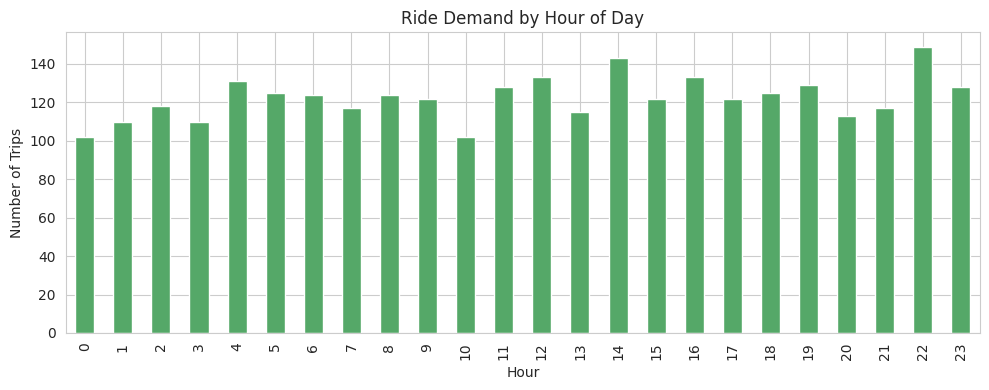

In [35]:
fig, ax = plt.subplots(figsize=(10, 4))
trips.groupby("hour")["trip_id"].count().plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Ride Demand by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Number of Trips")
plt.tight_layout()
plt.savefig("../output/ride_demand_by_hour.png", dpi=120)
plt.show()


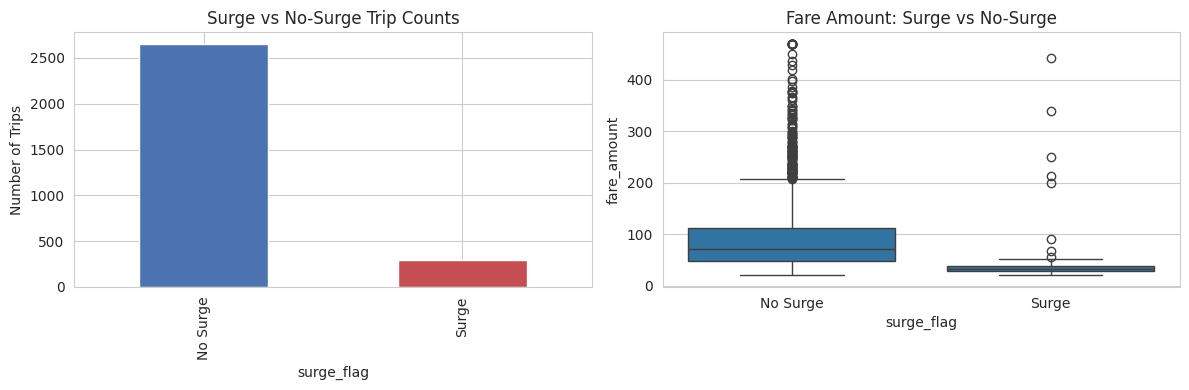

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

surge_counts = trips["surge_flag"].value_counts().rename({0: "No Surge", 1: "Surge"})
surge_counts.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("Surge vs No-Surge Trip Counts")
axes[0].set_ylabel("Number of Trips")

sns.boxplot(data=trips, x="surge_flag", y="fare_amount", ax=axes[1])
axes[1].set_xticklabels(["No Surge", "Surge"])
axes[1].set_title("Fare Amount: Surge vs No-Surge")

plt.tight_layout()
plt.savefig("../output/surge_vs_nosurge.png", dpi=120)
plt.show()


In [37]:
print("Pipeline complete.")
print(f"Final model-ready dataset: {final_dataset.shape[0]} rows x {final_dataset.shape[1]} columns")
print("Exported to output/final_prepared_rides_dataset.csv")


Pipeline complete.
Final model-ready dataset: 2942 rows x 61 columns
Exported to output/final_prepared_rides_dataset.csv
